In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import uniform

In [2]:
def psi(r,b,phi0=0):
    phi=-1/np.sqrt(r**2+b**2)
    return -phi+phi0

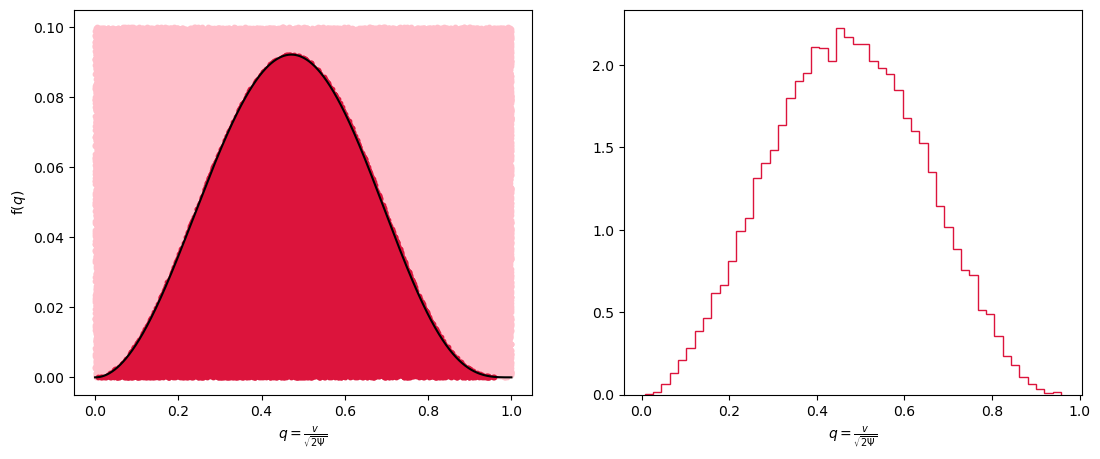

In [3]:
f = lambda x: (1-x**2)**(7/2)*x**2

n_rs=100000 #number of particles

xg = np.linspace(0,1,n_rs)
fig, ax = plt.subplots(1,2,figsize=(13,5))
ax[0].plot(xg,f(xg),c='k')


ymax = 0.1
x = np.random.uniform(0,1,n_rs) 
y = np.random.uniform(0,ymax,n_rs)


ax[0].scatter(x[y>f(x)],y[y>f(x)],c='pink',s=10)
ax[0].scatter(x[y<f(x)],y[y<f(x)],c='crimson',s=10)

ax[0].set_xlabel(r'$q=\frac{v} { \sqrt{2 \Psi} }$')
ax[0].set_ylabel('f$(q)$')

#plt.show()
goodpoints = x[y<f(x)]


ax[1].hist(goodpoints,bins=50,density=True,histtype='step',color='crimson')
ax[1].set_xlabel(r'$q=\frac{v} { \sqrt{2 \Psi} }$');

In order to initialize the perturber we need to choose M,  $r_M(t_{in})$, $v_M(t_{in}) $ to ensure that over the integration time dynamical friction effects will be appreciable.

In [69]:
n_part = 10000
mass_M = 1e-3

In [70]:

def generate_treecode_ic(filename, X_M, v_M, N=n_part, b=1.0, mass_M=mass_M): #N set for the numer of particle while b is arbitrary set to 1 

    xM, yM, zM = X_M
    vxM, vyM, vzM = v_M
    
    masses = (np.ones(N-1)-mass_M)/(N-1) #total mass 1

    phi = np.random.uniform(0, 2*np.pi, N)
    costheta = np.random.uniform(-1, 1, N)
    u = np.random.uniform(0, 1, N)
    
    theta = np.arccos(costheta)
    r=np.sqrt(b**2*u**(2/3)/(1-u**(2/3)))

    x = r*np.sin(theta)*np.cos(phi)
    y = r*np.sin(theta)*np.sin(phi)
    z = r*np.cos(theta)

    f = lambda q: (1-q**2)**(7/2)*q**2

    ymax = 0.1
    q=np.array([])

    while len(q)<N:
        x_rej = np.random.uniform(0,1,1)
        y_rej = np.random.uniform(0,ymax,1)
    
        if y_rej<f(x_rej):
            q=np.append(q,x_rej)

    #q=1 #q must be sampled with rejection sampling
    v = q*np.sqrt(2*psi(r,b))

    phi = np.random.uniform(0, 2*np.pi, N)
    costheta = np.random.uniform(-1, 1, N)    
    theta = np.arccos(costheta)
    
    vx = v*np.sin(theta)*np.cos(phi)
    vy = v*np.sin(theta)*np.sin(phi)
    vz = v*np.cos(theta)

    with open(filename, 'w') as f:
        f.write(f"{N}\n")         # Npart
        f.write("3\n")            # N of dimensions
        f.write("0.0\n")          # time
        
        # Array of masses
        f.write(f"{mass_M:.8e}\n")
        for m in masses:
            f.write(f"{m:.8e}\n")
            
        # Array of positions
        f.write(f"{xM:.8e} {yM:.8e} {zM:.8e}\n")
        for i in range(N-1):
            f.write(f"{x[i]:.8e} {y[i]:.8e} {z[i]:.8e}\n")
            
        # Array of velocities
        f.write(f"{vxM:.8e} {vyM:.8e} {vzM:.8e}\n")
        for i in range(N-1):
            f.write(f"{vx[i]:.8e} {vy[i]:.8e} {vz[i]:.8e}\n")

    return x,y,z, vx,vy,vz

In [71]:
from galpy import potential
rM_initial = 0.05
pp = potential.PlummerPotential(amp=1.,b=1.)
vc_pot = potential.calcRotcurve(pp,rM_initial)
vc_pot[0]

0.049906454609253185

In [73]:
filename='IC_df.txt'
xin,yin,zin, vxin,vyin,vzin=generate_treecode_ic(filename, X_M=[rM_initial,0,0], v_M=[0,vc_pot[0],0])

In [74]:
def load_all_snapshots(filename, N=n_part):
    snapshots = []
    
    with open(filename, 'r') as f:
        # Leggiamo tutto e puliamo da righe vuote
        lines = [l.strip() for l in f.readlines() if l.strip()]
    
    i = 0
    total_lines = len(lines)
    
    # Uno snapshot completo occupa: 4 (header) + N (masse) + N (posizioni) + N (velocità)
    lines_per_snapshot = 3 + 3 * N
    
    #print(f"Righe totali nel file: {total_lines}")
    
    while i + lines_per_snapshot <= total_lines:
        try:
            # Header
            n_part = float(lines[i])
            # Se n_part non è quello atteso, il file è corrotto o diverso
            if n_part != N:
                print(f"Attenzione: trovato N={n_part} alla riga {i}, atteso {N}")
                i += 1
                continue
                
            t_now = float(lines[i+2])
            
            # Indici dei blocchi
            m_start = i + 3
            p_start = m_start + N
            v_start = p_start + N
            
            # Caricamento dati con conversione veloce
            # Masse
            m = np.array(lines[m_start : p_start], dtype=float)
            
            # Posizioni (ogni riga ha 3 numeri separati da spazio)
            pos = np.array([l.split() for l in lines[p_start : v_start]], dtype=float)
            
            # Velocità
            vel = np.array([l.split() for l in lines[v_start : v_start + N]], dtype=float)
            
            snapshots.append({
                'time': t_now,
                'm': m,
                'pos': pos,
                'vel': vel
            })
            
            #print(f"Caricato snapshot al tempo t = {t_now}")
            
            # Vai all'inizio del prossimo snapshot
            i += lines_per_snapshot
            
        except Exception as e:
            print(f"Errore alla riga {i}: {e}")
            i += 1
            
    if not snapshots:
        print("❌ Nessuno snapshot salvato. Verifica che N sia corretto (nel file leggo 10000).")
    else:
        print(f"✅ Totale snapshot caricati: {len(snapshots)}")
        
    return snapshots

In [75]:
output_path = 'out.txt'

In [81]:
frames  = load_all_snapshots(output_path, n_part)
print(f"Successfully parsed {len(frames)} snapshots.")

✅ Totale snapshot caricati: 201
Successfully parsed 201 snapshots.


In [82]:
xfin = frames[-1]['pos'][:,0]
yfin = frames[-1]['pos'][:,1]
zfin = frames[-1]['pos'][:,2]

0.0 % of the mass is inside a radius of -0.8170766423717543


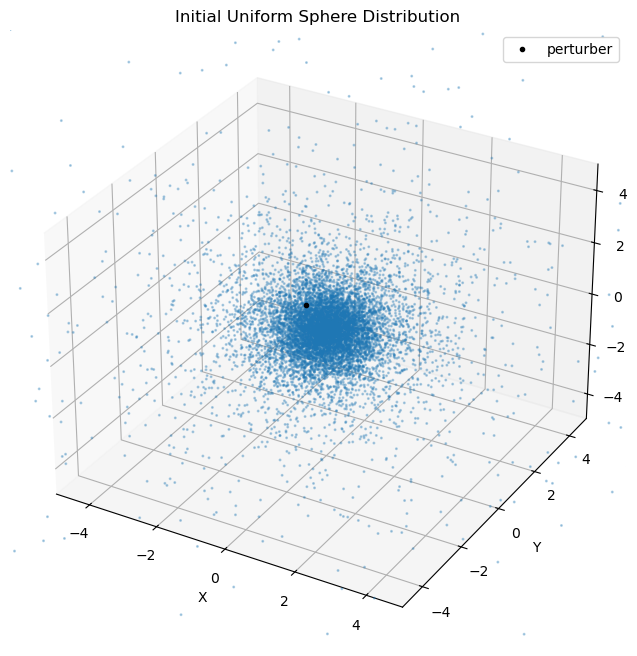

In [83]:
from mpl_toolkits.mplot3d import Axes3D # Required for 3D plots

def visualize_sphere_distribution(x,y,z, R, title="Initial Uniform Sphere Distribution"):
    """
    Visualizes the 3D distribution of particles in a sphere.

    Parameters:
        positions: Nx3 NumPy array of particle positions (x, y, z)
        R: The nominal radius of the sphere
        title: Title for the plot
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot particles
    
    ax.scatter(x[1:], y[1:], z[1:], s=5, alpha=0.3, marker='.',zorder=1)
    ax.plot(x[0], y[0], z[0], alpha=1, marker='.',color='k',label='perturber',zorder=1e4,linestyle='')

    r=x**2+y**2+z**2
    print(np.sum(r<R)/n_part*100, "% of the mass is inside a radius of", R)

    # Set labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)

    # Set equal aspect ratio
    # This ensures the sphere doesn't look squashed
    max_range = np.array([x.max()-x.min(),
                          y.max()-y.min(),
                          z.max()-z.min()]).max() / 2.0

    mid_x = (x.max()+x.min()) * 0.5
    mid_y = (y.max()+y.min()) * 0.5
    mid_z = (z.max()+z.min()) * 0.5
   
    #ax.set_xlim(mid_x - max_range, mid_x + max_range)
    #ax.set_ylim(mid_y - max_range, mid_y + max_range)
    #ax.set_zlim(mid_z - max_range, mid_z + max_range)

    ax.set_xlim(-5,5)
    ax.set_ylim(-5,5)
    ax.set_zlim(-5,5)
    ax.legend()

    plt.show()


visualize_sphere_distribution(xin,yin,zin,xin[0])

40.17 % of the mass is inside a radius of 1.3


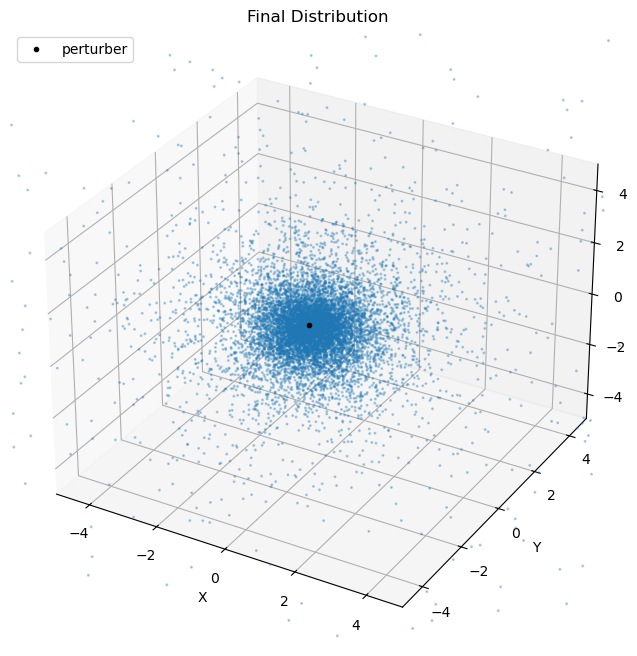

In [84]:
visualize_sphere_distribution(xfin,yfin,zfin,1.3,title='Final Distribution')

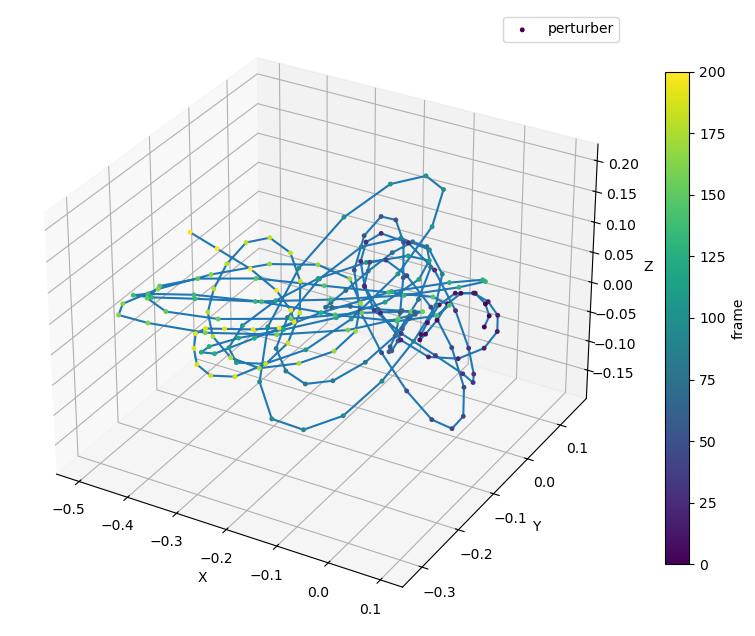

In [85]:

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
xM, yM, zM = [],[],[]
# Plot particles
for i in range(len(frames)):
    xM = np.append(xM,frames[i]['pos'][0,0] )
    yM = np.append(yM,frames[i]['pos'][0,1] )
    zM = np.append(zM,frames[i]['pos'][0,2] )
#ax.scatter(x[1:], y[1:], z[1:], s=5, alpha=0.3, marker='.',zorder=1)
color = range(len(frames))
pos = ax.scatter(xM, yM, zM, alpha=1,s=25, marker='.', c=color,label='perturber')
ax.plot(xM, yM, zM, alpha=1)
fig.colorbar(pos, label='frame',shrink=0.8)


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('')




ax.legend()

plt.show()


In [86]:
def find_density_center(pos, m, factor=0.9, tol=1e-5, min_particles=100):
    """Trova il centro di densità restringendo iterativamente la sfera."""
    # Punto di partenza: CM classico
    current_cm = np.sum(pos * m[:, np.newaxis], axis=0) / np.sum(m)
    distances = np.linalg.norm(pos - current_cm, axis=1)
    current_r = np.max(distances)
    diff = 1e10
    while diff > tol and len(pos) > min_particles:
        old_cm = current_cm.copy()
        current_r *= factor
        
        distances = np.linalg.norm(pos - current_cm, axis=1)
        mask = distances < current_r
        
        if np.sum(mask) < min_particles:
            break
            
        pos_subset = pos[mask]
        m_subset = m[mask]
        current_cm = np.sum(pos_subset * m_subset[:, np.newaxis], axis=0) / np.sum(m_subset)
        diff = np.linalg.norm(current_cm - old_cm)
    
    return current_cm

def plot_collapse_diagnostics_allsphere(snapshots):
    times = []
    rr = [] # Qui memorizziamo i raggi delle shell
    
    # Definiamo le frazioni di massa (10%, 20% ... 100%)
    fractions = np.linspace(0.1, 0.9, 9)
    
    print("Calcolo raggi lagrangiani con Shrinking Sphere...")
    
    for snap in snapshots:
        t = snap['time']
        pos = snap['pos']
        m = snap['m']
        
        # --- SHRINKING SPHERE ---
        
        center = find_density_center(pos, m)
        
       
        distances = np.linalg.norm(pos - center, axis=1)
        distances = np.sort(distances)
        # ----------------------------------------------
        
        times.append(t)
        
        current_shells = []
        for per in fractions:
            idx = int(per * (len(distances) - 1))
            current_shells.append(distances[idx])
        rr.append(current_shells)
    
    rr_array = np.array(rr).T
    
  
    plt.figure(figsize=(10, 7))
    
    for i, shell_data in enumerate(rr_array):
        label = f'{int(fractions[i]*100)}% Mass'
        color = plt.cm.viridis(i / len(rr_array))
        plt.plot(times, shell_data, label=label, color=color, lw=1.5, alpha=0.8,linestyle='--')
        #plt.scatter(times, shell_data, label=label, color=color, lw=1.5, alpha=0.8,marker='.',s=10)
    # Marcatori Fisici
    plt.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5, label='b')
    plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='b/2')

    plt.title("Lagrangian radii evolution")
    plt.xlabel("Time [IU]")
    plt.ylabel("Radius [IU]")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    #plt.yscale('log')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()


In [87]:
cm = []
for snap in frames:
        t = snap['time']
        pos = snap['pos']
        m = snap['m']
        
        center = find_density_center(pos, m)
        cm.append(center)

In [88]:
cm = np.array(cm)

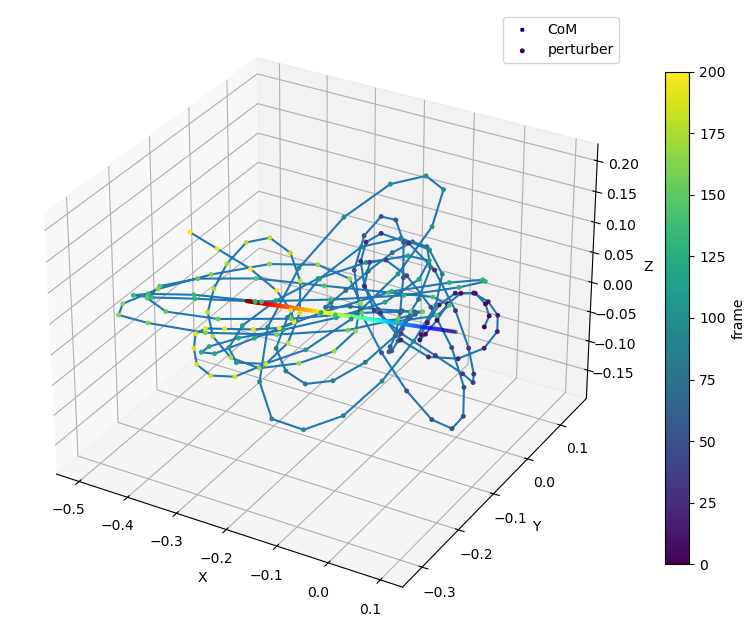

In [89]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
xM, yM, zM = [],[],[]
# Plot particles
for i in range(len(frames)):
    xM = np.append(xM,frames[i]['pos'][0,0] )
    yM = np.append(yM,frames[i]['pos'][0,1] )
    zM = np.append(zM,frames[i]['pos'][0,2] )
color = range(len(frames))
ax.scatter(cm[:,0], cm[:,1], cm[:,2], s=5, marker='x',zorder=1,c=color,label='CoM',cmap='jet' )
pos = ax.scatter(xM, yM, zM, alpha=1,s=25, marker='.', c=color,label='perturber')
ax.plot(xM, yM, zM, alpha=1)
fig.colorbar(pos, label='frame',shrink=0.8)


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('')




ax.legend()

plt.show()


In [90]:
def plot_collapse_diagnostics_allsphere(snapshots):
    times = []
    # We will store the results in a 2D array: (Number of Snapshots, 10 Shells)
    rr = []
    
    # Define the mass fractions we want to track
    fractions = np.linspace(0.1, 0.9, 9) # 10%, 20% ... 90%
    
    for snap in snapshots:
        t = snap['time']
        pos = snap['pos']
        
        # Center the data to remove numerical drift
        center = np.mean(pos, axis=0)
        #print(center)
        distances = np.sort(np.linalg.norm(pos - center, axis=1))
        
        times.append(t)
        
        # Calculate radius for each mass fraction
        current_shells = []
        for per in fractions:
            idx = int(per * (len(distances) - 1))
            current_shells.append(distances[idx])
        rr.append(current_shells)
    
    # Convert to array and transpose so each row is a time-series for a shell
    rr_array = np.array(rr).T
    
    plt.figure(figsize=(10, 7))
    
    # Plot each shell
    for i, shell_data in enumerate(rr_array):
        label = f'{int(fractions[i]*100)}% Mass'
        # Use a colormap to make it look professional
        color = plt.cm.viridis(i / len(rr_array))
        plt.plot(times, shell_data, label=label, color=color, lw=1.5, alpha=0.8)
    
    # Physics markers
    plt.axhline(y=1.0, color='b', linestyle=':', alpha=0.5, label='b')
    plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='b/2')

    plt.title("Evolution of Lagrangian Radii (Mass Shells)")
    plt.xlabel("Time")
    plt.ylabel("Radius")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

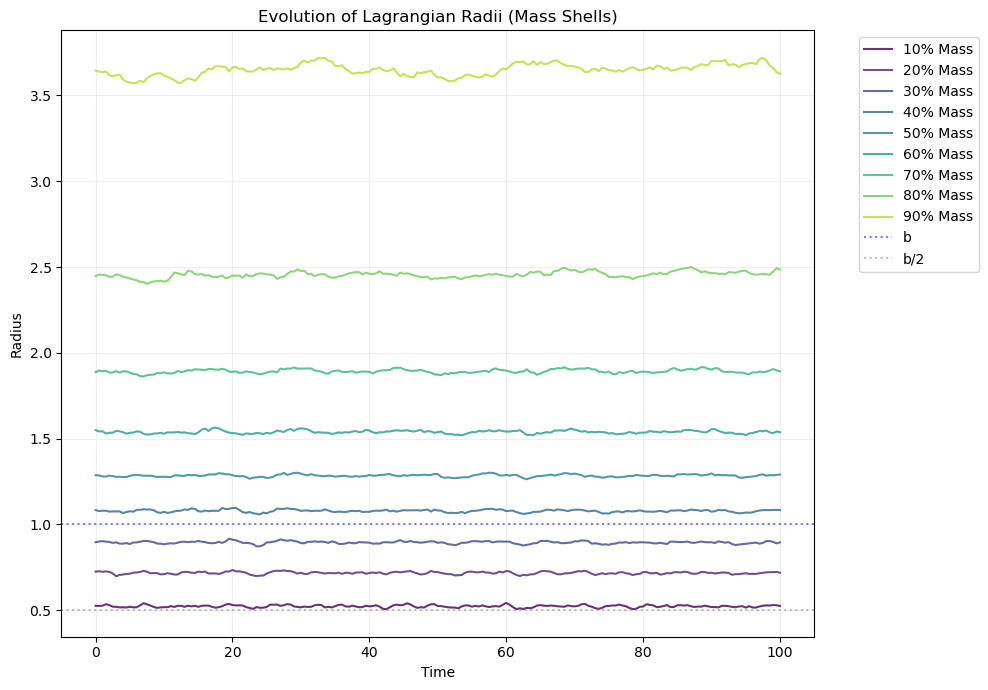

In [91]:
plot_collapse_diagnostics_allsphere(frames) 

In [92]:
def compute_potential(pos, m, G=1.0, epsilon=0.05): #siamo sicuri del softening?
    """
    Calcola il potenziale gravitazionale per ogni particella.
    epsilon è il 'softening parameter' per evitare divergenze.
    """
    num_particles = len(m)
    phi = np.zeros(num_particles)
    
    # Questo è un calcolo O(N^2), vettorizzato per velocità
    for i in range(num_particles):
        dx = pos[:, 0] - pos[i, 0]
        dy = pos[:, 1] - pos[i, 1]
        dz = pos[:, 2] - pos[i, 2]
        inv_dist = 1.0 / np.sqrt(dx**2 + dy**2 + dz**2 + epsilon**2)
        # Escludiamo l'auto-interazione (distanza zero)
        inv_dist[i] = 0
        phi[i] = -G * np.sum(m * inv_dist)
    
    return phi

In [93]:
from numba import njit, prange

@njit(parallel=True)
def compute_potential_numba(pos, m, G=1.0, epsilon=0.05):
    n = pos.shape[0]
    phi = np.zeros(n)
    eps2 = epsilon**2  
    
    for i in prange(n):
        xi = pos[i, 0]
        yi = pos[i, 1]
        zi = pos[i, 2]
        p_i = 0.0
        
        for j in range(n):
            # quadratic distance + softening
            dx = pos[j, 0] - xi
            dy = pos[j, 1] - yi
            dz = pos[j, 2] - zi
            
            dist_sq = dx*dx + dy*dy + dz*dz + eps2
            
            # exclusion of auto interaction
            if i != j:
                p_i -= m[j] / np.sqrt(dist_sq)
                
        phi[i] = p_i * G
        
    return phi

In [94]:
def plot_bound_unbound_analysis(snapshots, epsilon=0.05):
    times = []
    bound_mass_fraction = []
    
    plt.figure(figsize=(12, 4))
    
    for snap in snapshots:
        t = snap['time']
        pos = snap['pos']
        vel = snap['vel']
        m = snap['m']
        
        # 1. Calcolo Energia Cinetica Specifica: 0.5 * v^2
        v2 = np.sum(vel**2, axis=1)
        kinetic = 0.5 * v2
        
        # 2. Calcolo Potenziale (se non lo hai già nel file)
        potential = compute_potential_numba(pos, m) 
        
        # 3. Energia Totale
        total_energy = kinetic + potential
        
        # 4. Maschera per particelle legate
        is_bound = total_energy < 0
        num_bound = np.sum(is_bound)
        
        times.append(t)
        bound_mass_fraction.append(num_bound / len(m))
        
    # Grafico della frazione di massa legata nel tempo
    plt.plot(times, bound_mass_fraction, color='darkblue', lw=2)
    plt.title("Evolution of bound particles")
    plt.xlabel("Time")
    plt.ylabel("Bound particle fraction")
    plt.grid(True, alpha=0.3)
    plt.show()

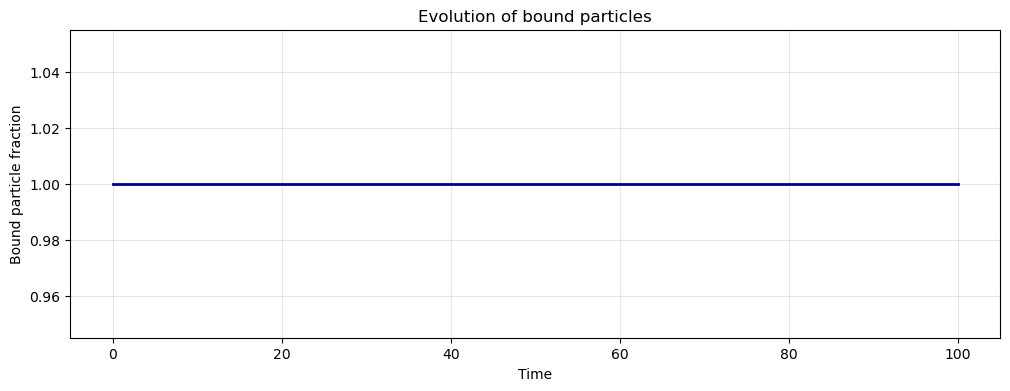

In [95]:
plot_bound_unbound_analysis(frames)

In [96]:
from matplotlib.animation import FuncAnimation

def animate_collapse(snapshots, R_limit=5.1):
    # Check if we actually have data
    if not snapshots:
        print("Error: No snapshots found. Check your parser.")
        return

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Initial data
    pos = snapshots[0]['pos']
    
    # 's' is point size. If N is large, keep s small (1 or 2)
    scat = ax.scatter(pos[0, 0], pos[0, 1], pos[0, 2], marker='.',c='k',zorder=1e4,linestyle='')
    scat2 = ax.scatter(pos[1:, 0], pos[1:, 1], pos[1:, 2], s=5, alpha=0.3)

    ax.set_xlim([-R_limit, R_limit])
    ax.set_ylim([-R_limit, R_limit])
    ax.set_zlim([-R_limit, R_limit])
    ax.set_title("Time: 0.00")

    def update(frame_idx):
        current_pos = snapshots[frame_idx]['pos']
        # For 3D, we must update using _offsets3d
        scat2._offsets3d = (current_pos[1:, 0], current_pos[1:, 1], current_pos[1:, 2])
        scat._offsets3d = (current_pos[0, 0], current_pos[0, 1], current_pos[0, 2])
        ax.set_title(f"Time: {snapshots[frame_idx]['time']:.3f}")
        return scat,

    # Increase interval if it's too fast, decrease if too slow
    ani = FuncAnimation(fig, update, frames=len(snapshots), interval=50, blit=False, repeat=True)
    
    return ani
    

In [221]:
# Run it
#ani =animate_collapse(frames)
from IPython.display import HTML
# ... after creating 'ani' ...
ani = animate_collapse(frames[::20])
HTML(ani.to_jshtml())

IndexError: invalid index to scalar variable.

IndexError: invalid index to scalar variable.

<Figure size 800x800 with 1 Axes>

In [ ]:
 scat._offsets3d?

In [228]:
xfin = frames[-1]['pos'][:,0]
yfin = frames[-1]['pos'][:,1]
zfin = frames[-1]['pos'][:,2]

vxfin = frames[-1]['vel'][:,0]
vyfin = frames[-1]['vel'][:,1]
vzfin = frames[-1]['vel'][:,2]

In [230]:
mass_M = 1e-2
masses = (np.ones(n_part-1)-mass_M)/(n_part-1) #total mass 1
with open('IC_df.txt', 'w') as f:
    f.write(f"{n_part}\n")         # Npart
    f.write("3\n")            # N of dimensions
    f.write("0.0\n")          # time
    
    # Array of masses
    f.write(f"{mass_M:.8e}\n")
    for m in masses:
        f.write(f"{m:.8e}\n")
        
    # Array of positions
    
    for i in range(n_part):
        f.write(f"{xfin[i]:.8e} {yfin[i]:.8e} {zfin[i]:.8e}\n")
        
    # Array of velocities
    for i in range(n_part):
        f.write(f"{vxfin[i]:.8e} {vyfin[i]:.8e} {vzfin[i]:.8e}\n")